# SatGen vs Galacticus: subhalo stripping in a $10^8\,M_\odot$ host

Compare two SatGen stripping prescriptions against a full-evolution Galacticus run
(one merger tree, single host $M_\mathrm{vir}=10^8\,M_\odot$ at $z=0$, subhalos dumped
across $z=10\to0$). Each subhalo's concentration $c=r_\mathrm{vir}/r_s$ is read straight
from Galacticus (`darkMatterOnlyRadiusVirial / darkMatterProfileScale`).

Five representative subhalos accreted at different redshifts, each evolved from infall to
$z=0$ under two methods and compared to Galacticus:

- **Green/DASH** — Green & van den Bosch 2019 transfer function (`evolve_satgen_green`,
  concentration-dependent stripping efficiency).
- **Du+24 hard** — second-order shell heating with a hard tidal-radius truncation
  (`evolve_heating_revirial`, `truncation='hard'`, `lt='Tormen98'`); the heating parameter
  set is fixed in the next cell.

The host is held static at each subhalo's infall-redshift host values $(M_\mathrm{vir}, r_s)$.
Galacticus carries $m_\mathrm{bound}$ as a scalar ledger on a frozen NFW (King62/Zentner+2005
tidal stripping, no tidal heating), so $m_\mathrm{bound}(t)$ and orbital $r(t)$ are direct
truth; a Galacticus *tidal track* is only a reference, its $m_\mathrm{bound}$ history
mapped through the Penarrubia+2010 relation.

The data file (`galacticus_subhalos.hdf5`) is assumed present in this directory but is gitignored.

In [1]:
import os, sys
import numpy as np
import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['font.size'] = 13
import matplotlib.pyplot as plt

# config.py loads etc/*.npy relative to cwd, so chdir to the repo root one level
# up (like the other scripts). Keep this dir (HERE) on sys.path to import the
# engine module and to hold the run cache.
HERE = os.getcwd()
sys.path.insert(0, HERE)
os.chdir(os.path.join(HERE, '..'))

import config as cfg
cfg.Mres = 0.1     # 1e8 host is 1e-4 of the usual 1e12; scale Mres from 1e3
# Length scales here are ~20x smaller than the 1e12/1e9 Du+24 fiducial (host
# rvir ~10 kpc, subhalo rs ~0.02-0.1 kpc, smallest data pericenters ~2e-3 kpc),
# so push Rres below the default 1e-3 to stay ~100x clear of every scale and
# resolve the deep end of the structural tracks. The clean nodes here are
# insensitive to this (peri >> Rres, rmax_min ~0.02 kpc): results are identical
# to <0.3% over Rres = 1e-3 ... 1e-6.
cfg.Rres = 1e-5

import galacticus_subhalo_evolution as gc

# Second-order shell-heating parameters for the hard truncation (lt='Tormen98'),
# calibrated to Du+24 and DASH N-body and frozen here so this notebook is self-contained.
HARD = {
    'alpha_s': 2.695899,
    'eps_h':   1.096738,
    'beta_h':  18.748125,
    'f_2':     0.365956,
    'gamma_h': 0.026043,
}


def fmt_pow10(m, sig=1):
    """LaTeX a x 10^b for clean mathtext titles (avoids the '6.4e+06' spacing)."""
    e = int(np.floor(np.log10(m)))
    return rf"{m/10**e:.{sig}f}\times10^{{{e}}}"


G = gc.Galacticus()
print("Du+24 hard heating params:")
for k, v in HARD.items():
    print(f"  {k:8s} {v:.4f}")
print(f"\nsnapshots: {len(G.z)}  z {G.z.min():.2f}-{G.z.max():.2f}  t {G.t.min():.2f}-{G.t.max():.2f} Gyr")
print(f"cfg.Mres={cfg.Mres}  cfg.Rres={cfg.Rres} kpc")

>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...


    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...


Du+24 hard heating params:
  alpha_s  2.6959
  eps_h    1.0967
  beta_h   18.7481
  f_2      0.3660
  gamma_h  0.0260

snapshots: 5000  z 0.00-10.00  t 0.47-13.79 Gyr
cfg.Mres=0.1  cfg.Rres=1e-05 kpc


## Which Galacticus stripping prescription?

Read straight from the output's parameter tree (cell below): King62 / Zentner+2005 tidal mass
loss, the same tidal-radius family SatGen uses. **No tidal heating** is enabled and
`darkMatterProfileDMO` is a frozen NFW, so the subhalo keeps its infall density — its King62
tidal radius stays large and it strips less than a heated (Du+24 `heatedMonotonic`) profile would.

In [2]:
import h5py
dec = lambda v: v.decode() if isinstance(v, bytes) else v
with h5py.File(gc.HDF5, 'r') as _f:
    par = _f['Parameters']
    strip_cls = dec(par.attrs['satelliteTidalStripping'])
    strip_par = {k: dec(v) for k, v in par['satelliteTidalStripping'].attrs.items()}
    lt_cls  = dec(par.attrs.get('satelliteTidalStrippingRadius', '<none>'))
    dmo_cls = dec(par.attrs['darkMatterProfileDMO'])
    ops = [dec(par['nodeOperator'].attrs[k]) for k in
           sorted(par['nodeOperator'].attrs, key=lambda k: int(k[len('nodeOperator['):-1]))]
    heat = [k for k in list(par.attrs) + list(par.keys()) if 'heat' in k.lower()]
    th_max = float(np.abs(_f['Outputs']['Output2500']['nodeData']
                          ['satelliteTidalHeatingNormalized'][()]).max())
print(f"satelliteTidalStripping       = {strip_cls}  "
      f"(efficiency={strip_par['efficiency']}, "
      f"useDynamicalTimeScale={strip_par['useDynamicalTimeScale']} -> T = orbital period)")
print(f"satelliteTidalStrippingRadius = {lt_cls}")
print(f"darkMatterProfileDMO          = {dmo_cls}  "
      "(Du+24 shell heating would be 'heatedMonotonic')")
print(f"tidal-heating params in tree  = {heat or 'none'}")
print(f"satelliteTidalHeatingNormalized max (Output2500) = {th_max}")
print(f"node operators = {ops}")

satelliteTidalStripping       = zentner2005  (efficiency=2.5, useDynamicalTimeScale=false -> T = orbital period)
satelliteTidalStrippingRadius = king1962
darkMatterProfileDMO          = NFW  (Du+24 shell heating would be 'heatedMonotonic')
tidal-heating params in tree  = none
satelliteTidalHeatingNormalized max (Output2500) = 0.0
node operators = ['cosmicTime', 'DMOInterpolate', 'darkMatterProfileScaleSet', 'darkMatterProfileScaleInterpolate', 'satelliteMergingTime', 'satelliteOrbit', 'satelliteTidalMassLoss', 'satelliteMinimumDistance', 'timeFirstInfall']


## Pick representative subhalos

From the $z=0$ satellites, keep ones with infall $M_\mathrm{vir}>10^5\,M_\odot$ (resolved),
actually stripped but still alive ($10^{-3}<f_b<0.9$), starting near the host virial radius
at infall (clean infallers, not backsplash). The five marked `<--` below are evolved;
node 6110 ($z_\mathrm{inf}=9.49$) is the earliest resolved survivor.

In [3]:
# five subhalos spread across infall redshift; 4/16/30/46 are clean infallers
# (r0 ~ rvir), 6110 is the earliest resolved survivor (z_inf=9.49, M_inf~1.3e5,
# sampled a bit inside rvir). Earlier/lower-mass infallers are too noisy.
NODES = [4, 16, 30, 46, 6110]

# z=0 satellites: the resolved, stripped-but-alive candidate pool, plus our picks
s0 = G.snaps[0]
sub = np.where(s0['nodeIsIsolated'] == 0)[0]
rows = []
for j in sub:
    nid = int(s0['nodeIndex'][j])
    Minf = float(s0['basicMass'][j]); Mfin = float(s0['satelliteBoundMass'][j])
    zi = G.z[np.argmin(np.abs(G.t - s0['basicTimeLastIsolated'][j]))]
    if (Minf > 1e5 and 1e-3 < Mfin/Minf < 0.9) or nid in NODES:
        rows.append((nid, zi, Minf, Mfin, Mfin/Minf))
rows.sort(key=lambda r: r[1])
print(" node   z_inf   Minf       Mfin       f_b      r0/rvir  pick")
for nid, zi, Minf, Mfin, fb in rows:
    ic = gc.infall_ics(G, nid)
    mark = '  <--' if nid in NODES else ''
    print(f" {nid:5d}  {zi:5.2f}  {Minf:.2e}  {Mfin:.2e}  {fb:.4f}   {ic['r0']/ic['rvir_host']:.2f}{mark}")

 node   z_inf   Minf       Mfin       f_b      r0/rvir  pick
     4   0.13  6.42e+06  2.55e+06  0.3964   0.94  <--
  8526   0.20  5.20e+05  1.17e+04  0.0224   0.84
    10   0.45  2.56e+05  1.77e+05  0.6927   0.98
    16   0.59  1.29e+06  1.04e+06  0.8060   0.95  <--
    20   0.71  3.99e+05  2.80e+05  0.7029   0.97
    22   0.76  2.87e+06  2.21e+06  0.7721   0.96
  5029   1.16  1.41e+05  9.58e+03  0.0681   0.74
    30   1.92  2.28e+05  7.30e+04  0.3206   0.95  <--
    46   3.28  1.22e+05  1.56e+04  0.1284   0.97  <--
  5051   4.20  1.38e+05  1.45e+04  0.1051   0.59
  6110   9.49  1.31e+05  2.45e+04  0.1867   0.82  <--


## Run the evolutions

Green/DASH and the Du+24 hard model, infall $\to z=0$, static infall-host. Both engines are
adaptive (`step_frac=0.01`).

In [4]:
import pickle

# cache RUNS keyed on (data file, nodes, params, Mres, Rres) so plot-only edits
# don't recompute the evolutions. The data file enters via path + size so swapping
# the hdf5 invalidates automatically; still delete the cache after editing
# galacticus_subhalo_evolution.run_node.
CACHE = os.path.join(HERE, 'galacticus_runs_cache.pkl')
_CACHE_NAME = os.path.basename(CACHE)
sig = (gc.HDF5, os.path.getsize(gc.HDF5), tuple(NODES),
       tuple(sorted(HARD.items())), cfg.Mres, cfg.Rres)

RUNS = None
if os.path.exists(CACHE):
    with open(CACHE, 'rb') as fh:
        cached = pickle.load(fh)
    if cached.get('sig') == sig:
        RUNS = cached['runs']
        print(f"loaded cached RUNS from {_CACHE_NAME}")
if RUNS is None:
    RUNS = {nid: gc.run_node(G, nid, HARD) for nid in NODES}
    with open(CACHE, 'wb') as fh:
        pickle.dump({'sig': sig, 'runs': RUNS}, fh)
    print(f"computed RUNS and cached to {_CACHE_NAME}")

def ff(r):
    m = r.m[np.isfinite(r.m)]; return m[-1] / m[0]
for nid in NODES:
    o = RUNS[nid]; ic = o['ic']
    print(f"node {nid:5d}  z_inf={ic['z']:.2f}  tmax={ic['tmax']:4.1f} Gyr  c_sub={ic['c_sub']:4.1f}"
          f" | final f_b  green={ff(o['green']):.2e}  hard={ff(o['hard']):.2e}  "
          f"gal={o['gal']['m_over_m0'][-1]:.2e}")

loaded cached RUNS from galacticus_runs_cache.pkl
node     4  z_inf=0.13  tmax= 1.7 Gyr  c_sub=46.9 | final f_b  green=5.08e-01  hard=2.75e-01  gal=3.96e-01
node    16  z_inf=0.59  tmax= 5.8 Gyr  c_sub=33.6 | final f_b  green=7.44e-01  hard=7.58e-01  gal=8.06e-01
node    30  z_inf=1.92  tmax=10.4 Gyr  c_sub= 7.9 | final f_b  green=3.71e-02  hard=6.37e-02  gal=3.21e-01
node    46  z_inf=3.27  tmax=11.8 Gyr  c_sub= 4.1 | final f_b  green=3.01e-04  hard=2.67e-02  gal=1.28e-01
node  6110  z_inf=9.49  tmax=13.3 Gyr  c_sub= 4.3 | final f_b  green=1.01e-05  hard=1.87e-05  gal=1.87e-01


## Mass loss: $m_\mathrm{bound}(t)$

Bound mass relative to infall vs time since infall.

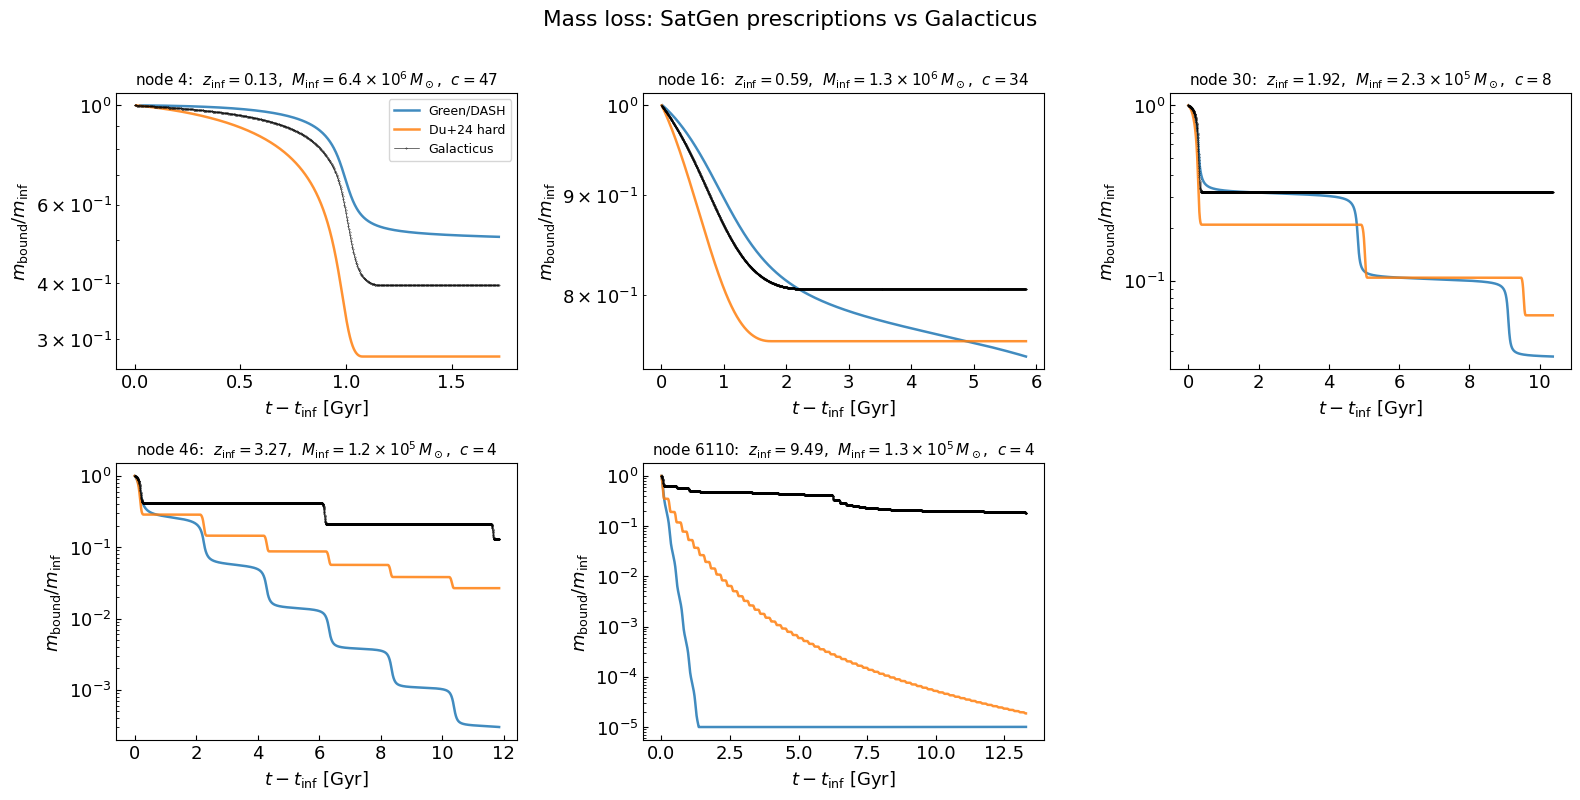

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False)
for ax, nid in zip(axes.flat, NODES):
    o = RUNS[nid]; ic = o['ic']
    for r, c, lab in [(o['green'], 'C0', 'Green/DASH'), (o['hard'], 'C1', 'Du+24 hard')]:
        g = np.isfinite(r.t) & np.isfinite(r.m)
        ax.plot(r.t[g], r.m[g]/r.m[g][0], color=c, lw=1.8, alpha=0.85, label=lab)
    gal = o['gal']
    ax.plot(gal['t_anchor'], gal['m_anchor'], 'k.-', ms=0.5, lw=0.4, label='Galacticus')
    ax.set_yscale('log')
    ax.set_title(f"node {nid}:  $z_\\mathrm{{inf}}={ic['z']:.2f}$,  "
                 f"$M_\\mathrm{{inf}}={fmt_pow10(ic['Mvir'])}\\,M_\\odot$,  $c={ic['c_sub']:.0f}$",
                 fontsize=11)
    ax.set_xlabel('$t - t_\\mathrm{inf}$ [Gyr]'); ax.set_ylabel('$m_\\mathrm{bound}/m_\\mathrm{inf}$')
for ax in axes.flat[len(NODES):]:
    ax.axis('off')
axes.flat[0].legend(fontsize=9)
fig.suptitle('Mass loss: SatGen prescriptions vs Galacticus', y=1.0)
fig.tight_layout()
plt.show()

## Orbital radius: $r(t)$

Physical $r(t)$, then normalized to the host virial radius. Our host is static at infall while
Galacticus's grows, so the physical orbits offset for the early infallers; dividing by the host
$r_\mathrm{vir}(t)$ (Galacticus) / $r_\mathrm{vir,infall}$ (ours) removes the virial
pseudo-evolution ($r_\mathrm{vir}\propto\rho_\mathrm{crit}^{-1/3}$).  The Galacticus track
uses `satellitePosition` (continuous across host-node switches; `positionOrbital` jumps when
a progenitor merges up the tree).

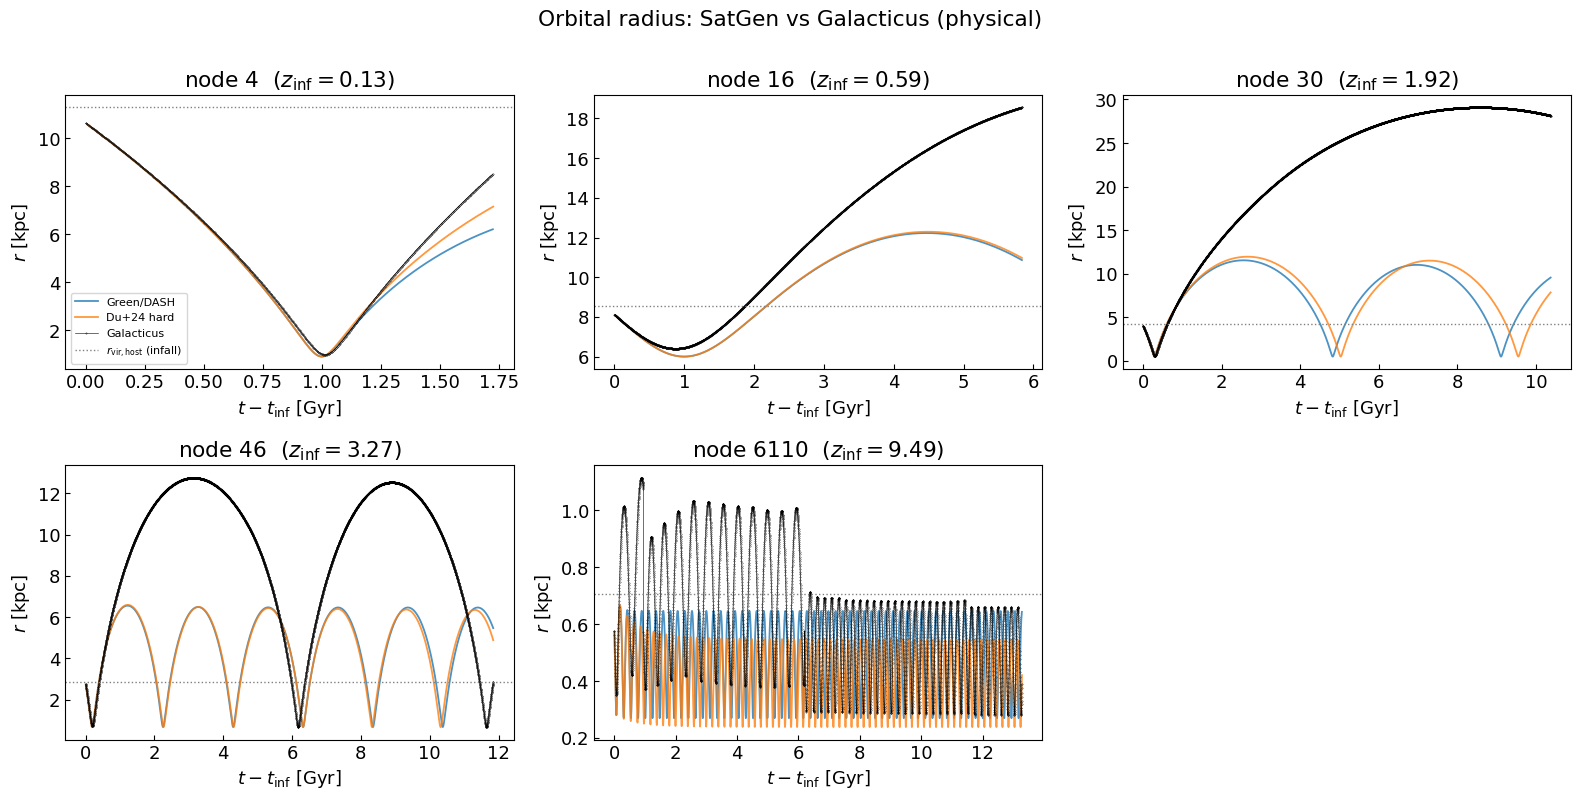

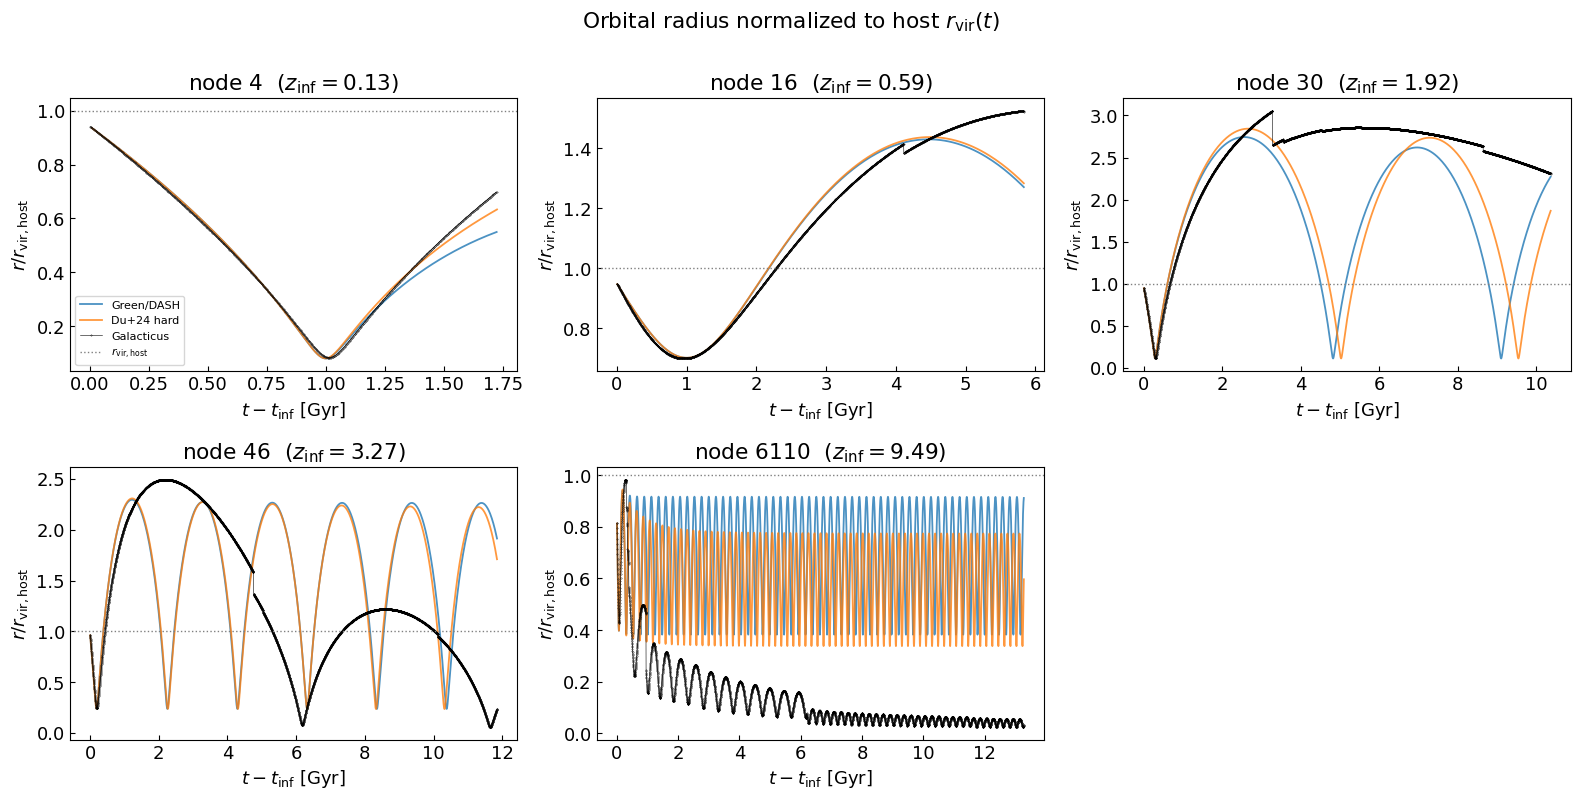

In [6]:
MODELS = [('green', 'C0', 'Green/DASH'), ('hard', 'C1', 'Du+24 hard')]

# Physical orbital radius. Galacticus track from satellitePosition (continuous across
# host-node switches); our orbits are integrated in the static infall host.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, nid in zip(axes.flat, NODES):
    o = RUNS[nid]; ic = o['ic']
    for key, c, lab in MODELS:
        r = o[key]; g = np.isfinite(r.t) & np.isfinite(r.r)
        ax.plot(r.t[g], r.r[g], color=c, lw=1.3, alpha=0.8, label=lab)
    gal = o['gal']
    ax.plot(gal['t_orb'], gal['r_orb'], 'k.-', ms=0.5, lw=0.4, label='Galacticus')
    ax.axhline(ic['rvir_host'], color='gray', ls=':', lw=1, label='$r_\\mathrm{vir,host}$ (infall)')
    ax.set_title(f"node {nid}  ($z_\\mathrm{{inf}}={ic['z']:.2f}$)")
    ax.set_xlabel('$t - t_\\mathrm{inf}$ [Gyr]'); ax.set_ylabel('$r$ [kpc]')
for ax in axes.flat[len(NODES):]:
    ax.axis('off')
axes.flat[0].legend(fontsize=8)
fig.suptitle('Orbital radius: SatGen vs Galacticus (physical)', y=1.0)
fig.tight_layout(); plt.show()

# Same orbits normalized to the host virial radius: Galacticus by its growing r_vir(t),
# ours by the static infall r_vir. Removes the virial pseudo-evolution (r_vir ~
# rho_crit^-1/3 grows z_inf -> 0 even at ~fixed host mass), the dominant orbit offset.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, nid in zip(axes.flat, NODES):
    o = RUNS[nid]; ic = o['ic']
    for key, c, lab in MODELS:
        r = o[key]; g = np.isfinite(r.t) & np.isfinite(r.r)
        ax.plot(r.t[g], r.r[g]/ic['rvir_host'], color=c, lw=1.3, alpha=0.8, label=lab)
    gal = o['gal']
    ax.plot(gal['t_orb'], gal['r_orb']/gal['rvir_orb'], 'k.-', ms=0.5, lw=0.4, label='Galacticus')
    ax.axhline(1.0, color='gray', ls=':', lw=1, label='$r_\\mathrm{vir,host}$')
    ax.set_title(f"node {nid}  ($z_\\mathrm{{inf}}={ic['z']:.2f}$)")
    ax.set_xlabel('$t - t_\\mathrm{inf}$ [Gyr]'); ax.set_ylabel('$r / r_\\mathrm{vir,host}$')
for ax in axes.flat[len(NODES):]:
    ax.axis('off')
axes.flat[0].legend(fontsize=8)
fig.suptitle('Orbital radius normalized to host $r_\\mathrm{vir}(t)$', y=1.0)
fig.tight_layout(); plt.show()

## Tidal tracks: $v_\mathrm{max}/v_\mathrm{max,0}$ vs $r_\mathrm{max}/r_\mathrm{max,0}$

Both methods produce structural tracks (markers show where each curve terminates, i.e. its
deepest strip). When Galacticus' Penarrubia+2010 DMO profile is enabled it maps the bound
fraction $x=m_\mathrm{bound}/m_\mathrm{infall}$ through the tidal-track relation
$g(x)=2^{\mu}x^{\eta}/(1+x)^{\mu}$ (same family as Du+24 eq. 19), with canonical NFW
exponents $\mu_V{=}0.4,\eta_V{=}0.3,\mu_R{=}{-}0.3,\eta_R{=}0.4$.

This run does not enable that profile: its `darkMatterProfileDMO` is a plain NFW frozen at
infall, so Galacticus output no $v_\mathrm{max}/r_\mathrm{max}$. The black Galacticus curve is
its bound-mass history mapped through the Penarrubia+2010 relation — where that history would
sit on the track, not structure it actually carried.

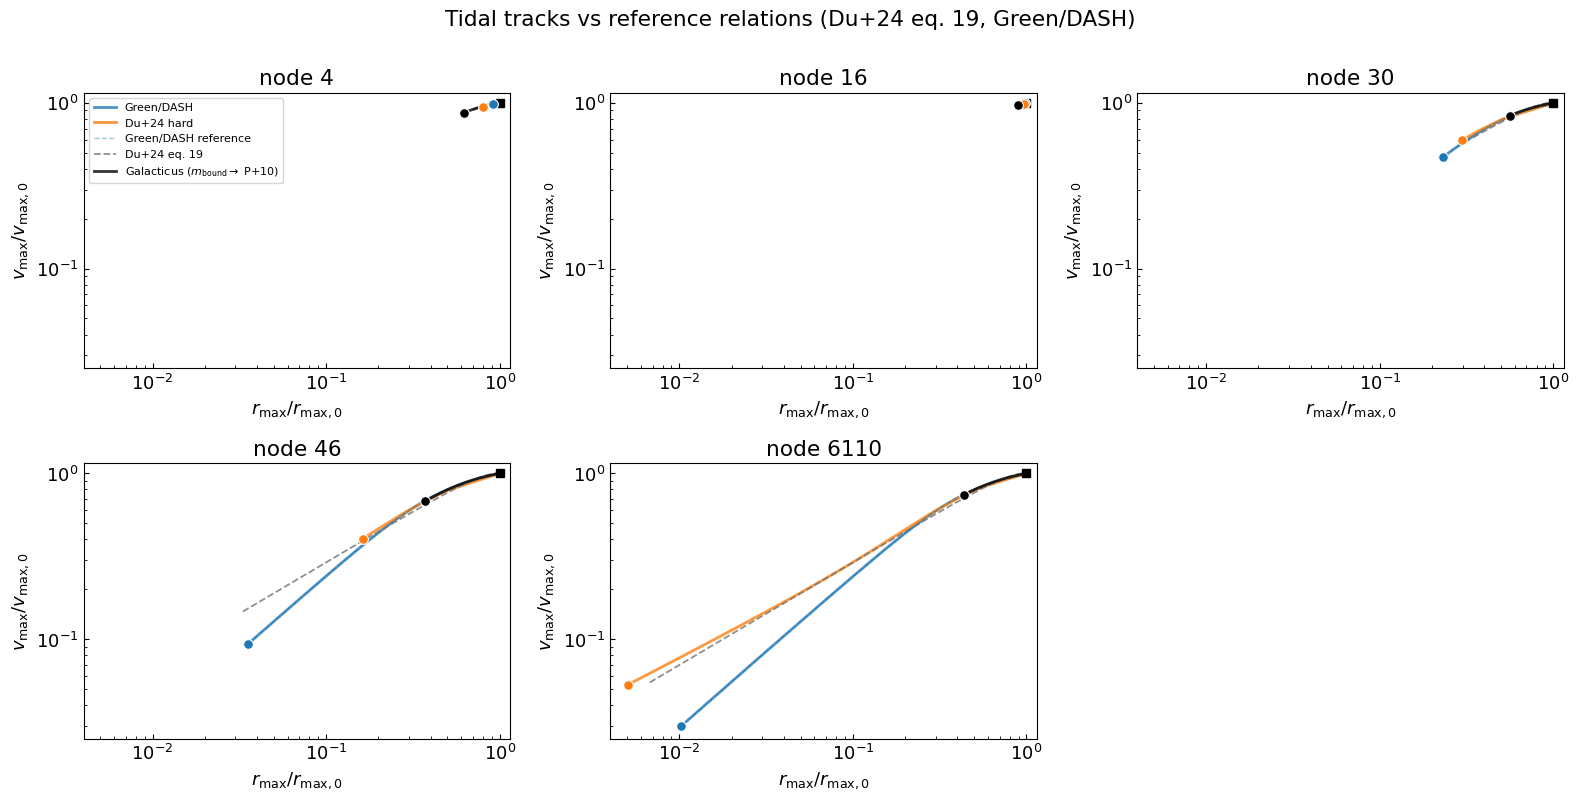

In [7]:
def _fbmin(r):
    m = r.m[np.isfinite(r.m)]
    return m.min() / m[0]

# common axis limits across panels so mild-stripping nodes (16 barely moves off (1,1))
# aren't auto-zoomed into a sub-percent arc; spans the deepest strip (node 6110).
TRACK_XLIM, TRACK_YLIM = (4e-3, 1.15), (2.5e-2, 1.15)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, nid in zip(axes.flat, NODES):
    o = RUNS[nid]; gal = o['gal']
    for r, c, lab in [(o['green'], 'C0', 'Green/DASH'), (o['hard'], 'C1', 'Du+24 hard')]:
        g = np.isfinite(r.rmax) & np.isfinite(r.vmax)
        Rr, Vv = r.rmax[g]/r.rmax0, r.vmax[g]/r.vmax0
        ax.plot(Rr, Vv, color=c, lw=2, alpha=0.8, label=lab)
        # mark where the curve terminates (deepest strip) so it's visible even
        # when hidden behind another track
        ax.plot(Rr[-1], Vv[-1], 'o', color=c, ms=7, mec='white', mew=0.8, zorder=6)
    # no-orbit reference tracks, clipped to the bound-fraction range the actual
    # evolutions span -- thin/faint so the methods and Galacticus read as primary
    fb_lo = min(_fbmin(o['green']), _fbmin(o['hard']),
                float(np.nanmin(gal['m_anchor'])))
    _, R_gd, V_gd = gc.green_dash_track(o['ic']['c_sub'], o['ic']['Mvir'], fb_min=fb_lo)
    ax.plot(R_gd, V_gd, '--', color='C0', lw=1, alpha=0.4, label='Green/DASH reference')
    R_du, V_du = gc.du24_nfw_track(np.logspace(np.log10(fb_lo), 0, 200))
    ax.plot(R_du, V_du, '--', color='0.45', lw=1.3, alpha=0.8, label='Du+24 eq. 19')
    # Galacticus: its bound-mass ledger through the Penarrubia2010 tidal track
    # (the run keeps the NFW frozen and m_bound a decoupled scalar; this is where
    # that history would sit structurally)
    ax.plot(gal['track_R'], gal['track_V'], '-', color='k', lw=2, alpha=0.8,
            label='Galacticus ($m_\\mathrm{bound}\\to$ P+10)')
    ax.plot(gal['track_R'][-1], gal['track_V'][-1], 'o', color='k', ms=7,
            mec='white', mew=0.8, zorder=6)
    ax.plot(1, 1, 'ks', ms=6)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(*TRACK_XLIM); ax.set_ylim(*TRACK_YLIM)
    ax.set_title(f"node {nid}"); ax.set_xlabel('$r_\\mathrm{max}/r_\\mathrm{max,0}$')
    ax.set_ylabel('$v_\\mathrm{max}/v_\\mathrm{max,0}$')
for ax in axes.flat[len(NODES):]:
    ax.axis('off')
axes.flat[0].legend(fontsize=8)
fig.suptitle('Tidal tracks vs reference relations (Du+24 eq. 19, Green/DASH)', y=1.0)
fig.tight_layout()
plt.show()